Files extracted to: /content/data
Using CSV file: /content/data/data.csv


/tmp/ipython-input-38293789.py:41: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file, encoding='latin1')


Using column as x: no2
Epoch 0 | D Loss: 1.3840 | G Loss: 0.6843
Epoch 500 | D Loss: 1.3683 | G Loss: 0.8197
Epoch 1000 | D Loss: 1.2692 | G Loss: 0.7893
Epoch 1500 | D Loss: 1.3861 | G Loss: 0.6772
Epoch 2000 | D Loss: 1.3914 | G Loss: 0.6749
Epoch 2500 | D Loss: 1.3758 | G Loss: 0.7099


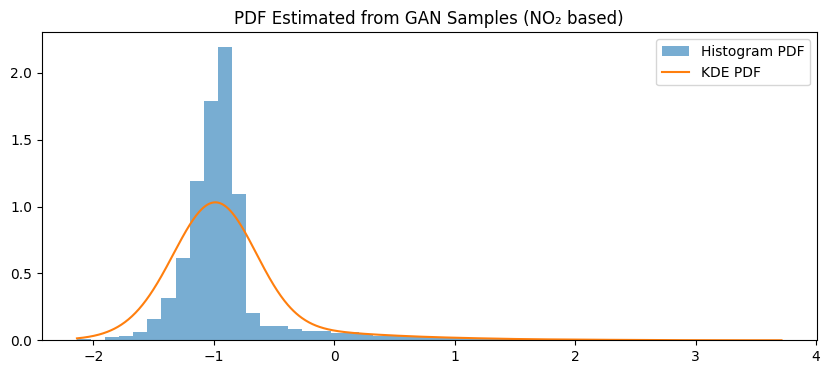

Transformation parameters → a_r = 0.5, b_r = 0.3


In [8]:


import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.neighbors import KernelDensity

# -------------------------
# STEP 1: Extract ZIP
# -------------------------
zip_path = "/content/archive (3).zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

# -------------------------
# STEP 2: Locate CSV
# -------------------------
csv_file = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

print("Using CSV file:", csv_file)
df = pd.read_csv(csv_file, encoding='latin1')

# -------------------------
# FORCE NO2 AS FEATURE x
# -------------------------
no2_col = None
for col in df.columns:
    if "no2" in col.lower():
        no2_col = col
        break

print("Using column as x:", no2_col)

x = df[no2_col].dropna().values
x = (x - x.mean()) / x.std()   # normalization
x = torch.tensor(x, dtype=torch.float32).view(-1, 1)

# -------------------------
# STEP 3: Transformation
# z = x + a_r sin(b_r x)
# -------------------------
roll_no = 102303830
r = roll_no % 5 + 1
a_r = 0.5 * r
b_r = 0.3 * r

z = x + a_r * torch.sin(b_r * x)

# -------------------------
# STEP 4: GAN Definition
# -------------------------
latent_dim = 5

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

# -------------------------
# STEP 5: Train GAN
# -------------------------
epochs = 3000
batch_size = 64

for epoch in range(epochs):
    idx = torch.randint(0, z.size(0), (batch_size,))
    real_samples = z[idx]

    # Discriminator
    noise = torch.randn(batch_size, latent_dim)
    fake_samples = G(noise)

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    D_loss = criterion(D(real_samples), real_labels) + \
             criterion(D(fake_samples.detach()), fake_labels)

    opt_D.zero_grad()
    D_loss.backward()
    opt_D.step()

    # Generator
    noise = torch.randn(batch_size, latent_dim)
    fake_samples = G(noise)
    G_loss = criterion(D(fake_samples), real_labels)

    opt_G.zero_grad()
    G_loss.backward()
    opt_G.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

# -------------------------
# STEP 6: PDF Estimation
# -------------------------
with torch.no_grad():
    gen_samples = G(torch.randn(10000, latent_dim)).numpy()

plt.figure(figsize=(10,4))
plt.hist(gen_samples, bins=50, density=True, alpha=0.6, label="Histogram PDF")

kde = KernelDensity(kernel='gaussian', bandwidth=0.3)
kde.fit(gen_samples)
x_plot = np.linspace(gen_samples.min(), gen_samples.max(), 1000).reshape(-1,1)
pdf = np.exp(kde.score_samples(x_plot))
plt.plot(x_plot, pdf, label="KDE PDF")

plt.title("PDF Estimated from GAN Samples (NO₂ based)")
plt.legend()
plt.show()

# -------------------------
# PRINT PARAMETERS
# -------------------------
print(f"Transformation parameters → a_r = {a_r}, b_r = {b_r}")